# Notebook 06: Doubly Robust Heterogeneous Effects

The project now has two complementary average-effect estimators:

- **Marginal structural model** from Notebook 04: models treatment assignment and uses inverse probability weights.
- **G-computation** from Notebook 05: models the future outcome directly and simulates treatment versus control.

This notebook adds a third strategy: **doubly robust estimation with AIPW scores**. AIPW stands for augmented inverse probability weighting. It combines the propensity model from Notebook 03 with the outcome models from Notebook 05.

The main question remains the same:

> What is the effect of a high-watch-exposure day on future 7-day interaction volume?

The new question in this notebook is:

> Even if the average effect is small, are there user-history segments where high-watch exposure appears more helpful or more harmful?

That second question matters in recommender systems. A global average can hide useful personalization signals. A treatment that has no average effect may still help some user states and hurt others.


## Why Doubly Robust Estimation Helps

AIPW is useful because it combines two nuisance models:

- a propensity model: `P(treatment = 1 | pre-treatment history)`;
- an outcome model: `E[outcome | treatment, pre-treatment history]`.

The AIPW score for each row is:

```text
m1(X) - m0(X)
+ A * (Y - m1(X)) / e(X)
- (1 - A) * (Y - m0(X)) / (1 - e(X))
```

Where:

- `A` is treatment;
- `Y` is the observed future outcome;
- `e(X)` is the propensity score;
- `m1(X)` is the predicted outcome under treatment;
- `m0(X)` is the predicted outcome under control.

AIPW is called doubly robust because, under standard assumptions, it can remain consistent if either the propensity model or the outcome model is correctly specified. In practice, it is also a strong diagnostic: if MSM, g-computation, and AIPW all tell a similar story, the conclusion is more credible.


## Setup

This cell imports the tools used for AIPW scoring, clustered bootstrap uncertainty, segment summaries, and effect-smoothing models. The effect-smoothing model is not treated as a definitive individual treatment effect model; it is used to make noisy AIPW pseudo-effects easier to summarize.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from lightgbm import LGBMRegressor
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="X does not have valid feature names")

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 150)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42


The notebook environment is ready for doubly robust estimation. The key inputs will be loaded from earlier notebooks, so this notebook focuses on combining nuisance predictions and summarizing heterogeneity.


## Locate Project Artifacts

This notebook needs three saved artifacts:

- the weighted panel with propensity scores from Notebook 03;
- the counterfactual outcome predictions from Notebook 05;
- the estimator comparison table from Notebook 05.

Loading these files keeps the project modular and avoids refitting nuisance models unnecessarily.


In [2]:
WEIGHTED_PANEL_RELATIVE_PATH = Path("data/processed/kuairec_long_term_weighted_panel.parquet")
GCOMP_COUNTERFACTUALS_RELATIVE_PATH = Path("data/processed/kuairec_long_term_gcomp_counterfactuals.parquet")
ESTIMATOR_COMPARISON_RELATIVE_PATH = Path("data/processed/kuairec_long_term_estimator_comparison.csv")

candidate_roots = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(
    (path for path in candidate_roots if (path / WEIGHTED_PANEL_RELATIVE_PATH).exists()),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not find {WEIGHTED_PANEL_RELATIVE_PATH}. Run Notebooks 03-05 first or run this notebook inside the project."
    )

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PANEL_PATH = PROJECT_ROOT / WEIGHTED_PANEL_RELATIVE_PATH
COUNTERFACTUALS_PATH = PROJECT_ROOT / GCOMP_COUNTERFACTUALS_RELATIVE_PATH
ESTIMATOR_COMPARISON_PATH = PROJECT_ROOT / ESTIMATOR_COMPARISON_RELATIVE_PATH

print(f"Project root: {PROJECT_ROOT}")
print(f"Weighted panel: {PANEL_PATH}")
print(f"G-computation counterfactuals: {COUNTERFACTUALS_PATH}")
print(f"Estimator comparison: {ESTIMATOR_COMPARISON_PATH}")
print(f"Processed output folder: {PROCESSED_DIR}")


Project root: /home/apex/Documents/ranking_sys
Weighted panel: /home/apex/Documents/ranking_sys/data/processed/kuairec_long_term_weighted_panel.parquet
G-computation counterfactuals: /home/apex/Documents/ranking_sys/data/processed/kuairec_long_term_gcomp_counterfactuals.parquet
Estimator comparison: /home/apex/Documents/ranking_sys/data/processed/kuairec_long_term_estimator_comparison.csv
Processed output folder: /home/apex/Documents/ranking_sys/data/processed


The required artifacts are present. This confirms the notebook can reuse the propensity and outcome nuisance predictions that were already created in a cross-fitted way.


## Load Propensity Scores and Outcome Nuisance Predictions

The weighted panel contains the treatment, outcome, propensity scores, and pre-treatment history. The counterfactual table contains `pred_y1` and `pred_y0` from the linear and LightGBM g-computation models.


In [3]:
panel = pd.read_parquet(PANEL_PATH)
panel["event_date"] = pd.to_datetime(panel["event_date"])
panel = panel.sort_values(["user_id", "event_date"]).reset_index(drop=True)

counterfactuals = pd.read_parquet(COUNTERFACTUALS_PATH)
counterfactuals["event_date"] = pd.to_datetime(counterfactuals["event_date"])

estimator_comparison = pd.read_csv(ESTIMATOR_COMPARISON_PATH)

PRIMARY_TREATMENT = "treatment"
PRIMARY_OUTCOME = "outcome"

print(f"Weighted panel shape: {panel.shape}")
print(f"Counterfactual table shape: {counterfactuals.shape}")
print(f"Outcome nuisance models: {sorted(counterfactuals['model'].unique())}")

display(panel[["user_id", "event_date", PRIMARY_TREATMENT, PRIMARY_OUTCOME, "propensity_logistic", "propensity_lightgbm"]].head())
display(counterfactuals.head())


Weighted panel shape: (4698, 40)
Counterfactual table shape: (9396, 10)
Outcome nuisance models: ['lightgbm', 'linear_ridge']


,user_id,event_date,treatment,outcome,propensity_logistic,propensity_lightgbm
0,14,2020-07-08,1,279.0000,0.5471,0.5266
1,14,2020-07-09,0,311.0000,0.6333,0.5373
2,14,2020-07-10,1,352.0000,0.4140,0.5234
3,14,2020-07-11,1,437.0000,0.5654,0.6503
4,14,2020-07-12,0,437.0000,0.5986,0.7418


,user_id,event_date,model,treatment,outcome,pred_observed,pred_y1,pred_y0,cate_hat,residual
0,14,2020-07-08,linear_ridge,1,279.0000,519.6987,519.6987,515.8710,3.8276,-240.6987
1,14,2020-07-09,linear_ridge,0,311.0000,497.2763,501.1040,497.2763,3.8276,-186.2763
2,14,2020-07-10,linear_ridge,1,352.0000,520.0026,520.0026,516.1750,3.8276,-168.0026
3,14,2020-07-11,linear_ridge,1,437.0000,495.6651,495.6651,491.8375,3.8276,-58.6651
4,14,2020-07-12,linear_ridge,0,437.0000,497.5665,501.3941,497.5665,3.8276,-60.5665


The loaded tables line up at the user-day level. The counterfactual table has one row per user-day per outcome model, which lets us compute AIPW estimates for multiple propensity/outcome model combinations.


## Merge Nuisance Predictions into an AIPW Base Table

The next cell joins propensity scores and pre-treatment covariates onto the counterfactual predictions. This produces the row-level table needed for AIPW scoring.


In [4]:
pre_treatment_covariates = [
    "lag_1_active_day",
    "lag_1_interactions",
    "lag_1_total_play_duration_sec",
    "lag_1_avg_watch_ratio",
    "lag_1_high_watch_share",
    "prior_3day_active_day",
    "prior_3day_interactions",
    "prior_3day_total_play_duration_sec",
    "prior_3day_avg_watch_ratio",
    "prior_3day_high_watch_share",
    "calendar_day_index",
    "panel_day_index",
    "day_of_week",
]

panel_for_merge = panel[
    [
        "user_id",
        "event_date",
        "propensity_logistic",
        "propensity_lightgbm",
        "analysis_weight",
        *pre_treatment_covariates,
    ]
].copy()

aipw_base = counterfactuals.merge(
    panel_for_merge,
    on=["user_id", "event_date"],
    how="left",
    validate="many_to_one",
)

required_aipw_columns = [
    PRIMARY_TREATMENT,
    PRIMARY_OUTCOME,
    "pred_y1",
    "pred_y0",
    "propensity_logistic",
    "propensity_lightgbm",
]
missing_rates = aipw_base[required_aipw_columns].isna().mean().rename("missing_rate").reset_index().rename(columns={"index": "column"})

display(missing_rates)
display(aipw_base.head())


,column,missing_rate
0,treatment,0.0000
1,outcome,0.0000
2,pred_y1,0.0000
3,pred_y0,0.0000
4,propensity_logistic,0.0000
5,propensity_lightgbm,0.0000


,user_id,event_date,model,treatment,outcome,pred_observed,pred_y1,pred_y0,cate_hat,residual,propensity_logistic,propensity_lightgbm,analysis_weight,lag_1_active_day,lag_1_interactions,lag_1_total_play_duration_sec,lag_1_avg_watch_ratio,lag_1_high_watch_share,prior_3day_active_day,prior_3day_interactions,prior_3day_total_play_duration_sec,prior_3day_avg_watch_ratio,prior_3day_high_watch_share,calendar_day_index,panel_day_index,day_of_week
0,14,2020-07-08,linear_ridge,1,279.0000,519.6987,519.6987,515.8710,3.8276,-240.6987,0.5471,0.5266,0.9131,1.0000,78.0000,655.4890,0.8415,0.4615,3.0000,127.0000,"1,144.8080",2.9900,1.5602,3,3,Wednesday
1,14,2020-07-09,linear_ridge,0,311.0000,497.2763,501.1040,497.2763,3.8276,-186.2763,0.6333,0.5373,1.3647,1.0000,22.0000,201.9010,0.9828,0.5000,3.0000,123.0000,"1,105.7340",2.8883,1.4833,4,4,Thursday
2,14,2020-07-10,linear_ridge,1,352.0000,520.0026,520.0026,516.1750,3.8276,-168.0026,0.4140,0.5234,1.2067,1.0000,55.0000,485.0390,0.8619,0.3636,3.0000,155.0000,"1,342.4290",2.6862,1.3252,5,5,Friday
3,14,2020-07-11,linear_ridge,1,437.0000,495.6651,495.6651,491.8375,3.8276,-58.6651,0.5654,0.6503,0.8836,1.0000,52.0000,606.2440,1.1380,0.5769,3.0000,129.0000,"1,293.1840",2.9827,1.4406,6,6,Saturday
4,14,2020-07-12,linear_ridge,0,437.0000,497.5665,501.3941,497.5665,3.8276,-60.5665,0.5986,0.7418,1.2466,1.0000,32.0000,284.7470,0.9337,0.5000,3.0000,139.0000,"1,376.0300",2.9336,1.4406,7,7,Sunday


The merged table has the ingredients for doubly robust scores: observed treatment, observed outcome, propensity scores, and predicted potential outcomes. Missingness should be zero for the required columns before any AIPW estimate is trusted.


## Define the AIPW Score

This helper computes the AIPW score for one propensity model and one outcome model. Propensities are clipped away from 0 and 1 to prevent a small number of near-impossible treatment assignments from dominating the residual correction.


In [5]:
def add_aipw_score(data, propensity_col, score_col, eps=0.01):
    result = data.copy()
    treatment = result[PRIMARY_TREATMENT].astype(float)
    outcome = result[PRIMARY_OUTCOME].astype(float)
    e_hat = result[propensity_col].astype(float).clip(eps, 1 - eps)
    m1_hat = result["pred_y1"].astype(float)
    m0_hat = result["pred_y0"].astype(float)

    result[f"{score_col}_e_clipped"] = e_hat
    result[score_col] = (
        (m1_hat - m0_hat)
        + treatment * (outcome - m1_hat) / e_hat
        - (1 - treatment) * (outcome - m0_hat) / (1 - e_hat)
    )
    return result

print("Defined AIPW score helper.")


Defined AIPW score helper.


The helper implements the doubly robust score formula. The score combines the model-implied treatment contrast with residual corrections from the observed treated and control rows.


## Compute AIPW Scores for Nuisance Model Combinations

This cell computes AIPW scores for four combinations:

- logistic propensity + linear outcome;
- logistic propensity + LightGBM outcome;
- LightGBM propensity + linear outcome;
- LightGBM propensity + LightGBM outcome.

The primary doubly robust specification is logistic propensity plus LightGBM outcome, because Notebook 03 showed logistic propensities were stable and Notebook 05 showed LightGBM had better outcome prediction.


In [6]:
propensity_specs = {
    "logistic_propensity": "propensity_logistic",
    "lightgbm_propensity": "propensity_lightgbm",
}

score_frames = []
for outcome_model in sorted(aipw_base["model"].unique()):
    model_data = aipw_base.query("model == @outcome_model").copy()
    for propensity_name, propensity_col in propensity_specs.items():
        score_name = f"aipw_{propensity_name}_{outcome_model}_outcome"
        scored = add_aipw_score(model_data, propensity_col, score_name, eps=0.01)
        scored["propensity_model"] = propensity_name
        scored["outcome_model"] = outcome_model
        scored["aipw_score"] = scored[score_name]
        scored["aipw_score_name"] = score_name
        score_frames.append(scored)

aipw_scores = pd.concat(score_frames, ignore_index=True)
PRIMARY_AIPW_SCORE_NAME = "aipw_logistic_propensity_lightgbm_outcome"

print(f"AIPW score rows: {len(aipw_scores):,}")
print(f"Primary AIPW score: {PRIMARY_AIPW_SCORE_NAME}")
display(aipw_scores[["user_id", "event_date", "propensity_model", "outcome_model", "aipw_score"]].head())


AIPW score rows: 18,792
Primary AIPW score: aipw_logistic_propensity_lightgbm_outcome


,user_id,event_date,propensity_model,outcome_model,aipw_score
0,14,2020-07-08,logistic_propensity,lightgbm,-182.3750
1,14,2020-07-09,logistic_propensity,lightgbm,245.6311
2,14,2020-07-10,logistic_propensity,lightgbm,-144.5768
3,14,2020-07-11,logistic_propensity,lightgbm,7.5475
4,14,2020-07-12,logistic_propensity,lightgbm,25.5266


The AIPW table now contains one score per user-day for each nuisance-model combination. The average of each score column is the corresponding doubly robust estimate.


## Summarize Doubly Robust Average Effects

This table averages the AIPW scores by nuisance model combination. It also reports the model-implied counterfactual means and the distribution of row-level scores.


In [7]:
aipw_results = (
    aipw_scores.groupby(["propensity_model", "outcome_model", "aipw_score_name"])
    .agg(
        n_rows=("aipw_score", "size"),
        n_users=("user_id", "nunique"),
        mean_y1_hat=("pred_y1", "mean"),
        mean_y0_hat=("pred_y0", "mean"),
        gcomp_component=("cate_hat", "mean"),
        aipw_ate=("aipw_score", "mean"),
        aipw_score_std=("aipw_score", "std"),
        aipw_p05=("aipw_score", lambda values: values.quantile(0.05)),
        aipw_median=("aipw_score", "median"),
        aipw_p95=("aipw_score", lambda values: values.quantile(0.95)),
        share_positive_score=("aipw_score", lambda values: (values > 0).mean()),
    )
    .reset_index()
)

aipw_results["relative_lift_vs_y0"] = aipw_results["aipw_ate"] / aipw_results["mean_y0_hat"]
aipw_results["is_primary_aipw"] = aipw_results["aipw_score_name"].eq(PRIMARY_AIPW_SCORE_NAME)

display(aipw_results)


,propensity_model,outcome_model,aipw_score_name,n_rows,n_users,mean_y1_hat,mean_y0_hat,gcomp_component,aipw_ate,aipw_score_std,aipw_p05,aipw_median,aipw_p95,share_positive_score,relative_lift_vs_y0,is_primary_aipw
0,lightgbm_propensity,lightgbm,aipw_lightgbm_propensity_lightgbm_outcome,4698,91,382.3398,382.3040,0.0359,1.9929,210.8940,-230.0220,2.0653,218.2429,0.5109,0.0052,False
1,lightgbm_propensity,linear_ridge,aipw_lightgbm_propensity_linear_ridge_outcome,4698,91,383.2312,380.9024,2.3288,0.0236,325.4178,-353.3088,6.5009,329.7477,0.5153,0.0001,False
2,logistic_propensity,lightgbm,aipw_logistic_propensity_lightgbm_outcome,4698,91,382.3398,382.3040,0.0359,1.0940,325.5438,-227.4167,1.9645,214.8106,0.5109,0.0029,True
3,logistic_propensity,linear_ridge,aipw_logistic_propensity_linear_ridge_outcome,4698,91,383.2312,380.9024,2.3288,-4.2621,462.7484,-351.1020,6.3363,322.5791,0.5151,-0.0112,False


The AIPW estimates add a third view of the average effect. Agreement across nuisance combinations would suggest the result is not driven by one particular propensity or outcome model.


## User-Cluster Bootstrap for AIPW Estimates

Each user contributes multiple days, so uncertainty should be clustered by user. This bootstrap resamples users and recomputes the average AIPW score for each nuisance combination. The nuisance predictions are kept fixed, so this is a practical uncertainty check for the score average rather than a full nuisance-refitting bootstrap.


In [8]:
def cluster_bootstrap_score_mean(data, score_col="aipw_score", group_col="user_id", n_bootstrap=400, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    user_ids = data[group_col].unique()
    user_groups = {user_id: group for user_id, group in data.groupby(group_col, sort=False)}
    rows = []
    for bootstrap_id in range(n_bootstrap):
        sampled_users = rng.choice(user_ids, size=len(user_ids), replace=True)
        sample = pd.concat([user_groups[user_id] for user_id in sampled_users], ignore_index=True)
        rows.append({"bootstrap_id": bootstrap_id, "estimate": sample[score_col].mean()})
    return pd.DataFrame(rows)

N_AIPW_BOOTSTRAP = 400
bootstrap_frames = []
for (propensity_model, outcome_model, score_name), group in aipw_scores.groupby(
    ["propensity_model", "outcome_model", "aipw_score_name"]
):
    boot = cluster_bootstrap_score_mean(group, n_bootstrap=N_AIPW_BOOTSTRAP)
    boot["propensity_model"] = propensity_model
    boot["outcome_model"] = outcome_model
    boot["aipw_score_name"] = score_name
    bootstrap_frames.append(boot)

aipw_bootstrap = pd.concat(bootstrap_frames, ignore_index=True)

aipw_bootstrap_summary = (
    aipw_bootstrap.groupby(["propensity_model", "outcome_model", "aipw_score_name"])
    .agg(
        bootstrap_reps=("estimate", "size"),
        bootstrap_mean=("estimate", "mean"),
        bootstrap_std=("estimate", "std"),
        ci_95_lower=("estimate", lambda values: values.quantile(0.025)),
        ci_95_upper=("estimate", lambda values: values.quantile(0.975)),
    )
    .reset_index()
)

aipw_results = aipw_results.merge(
    aipw_bootstrap_summary,
    on=["propensity_model", "outcome_model", "aipw_score_name"],
    how="left",
)

display(aipw_results)


,propensity_model,outcome_model,aipw_score_name,n_rows,n_users,mean_y1_hat,mean_y0_hat,gcomp_component,aipw_ate,aipw_score_std,aipw_p05,aipw_median,aipw_p95,share_positive_score,relative_lift_vs_y0,is_primary_aipw,bootstrap_reps,bootstrap_mean,bootstrap_std,ci_95_lower,ci_95_upper
0,lightgbm_propensity,lightgbm,aipw_lightgbm_propensity_lightgbm_outcome,4698,91,382.3398,382.3040,0.0359,1.9929,210.8940,-230.0220,2.0653,218.2429,0.5109,0.0052,False,400,1.8301,2.8635,-3.4280,7.5135
1,lightgbm_propensity,linear_ridge,aipw_lightgbm_propensity_linear_ridge_outcome,4698,91,383.2312,380.9024,2.3288,0.0236,325.4178,-353.3088,6.5009,329.7477,0.5153,0.0001,False,400,-0.3441,4.8857,-9.9116,8.8830
2,logistic_propensity,lightgbm,aipw_logistic_propensity_lightgbm_outcome,4698,91,382.3398,382.3040,0.0359,1.0940,325.5438,-227.4167,1.9645,214.8106,0.5109,0.0029,True,400,1.1991,5.0298,-7.3428,12.0178
3,logistic_propensity,linear_ridge,aipw_logistic_propensity_linear_ridge_outcome,4698,91,383.2312,380.9024,2.3288,-4.2621,462.7484,-351.1020,6.3363,322.5791,0.5151,-0.0112,False,400,-4.6326,7.2876,-21.6843,8.2386


The bootstrap intervals add uncertainty to the doubly robust estimates. If the intervals cross zero, the doubly robust estimate should be reported as uncertain even if the point estimate has a direction.


## Plot AIPW Estimates Across Nuisance Combinations

This plot shows the doubly robust estimates and bootstrap intervals. It helps diagnose whether one nuisance combination is an outlier.


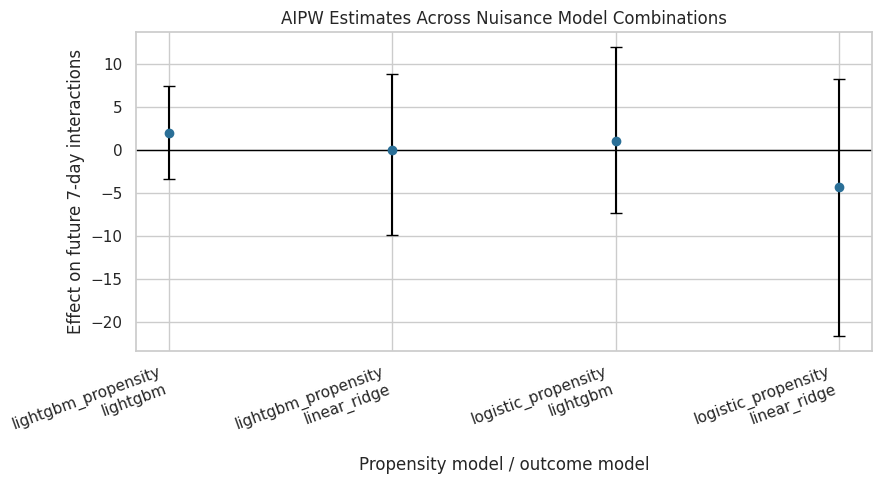

In [9]:
aipw_plot = aipw_results.copy()
aipw_plot["label"] = aipw_plot["propensity_model"] + "\n" + aipw_plot["outcome_model"]
aipw_plot["lower_error"] = aipw_plot["aipw_ate"] - aipw_plot["ci_95_lower"]
aipw_plot["upper_error"] = aipw_plot["ci_95_upper"] - aipw_plot["aipw_ate"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(
    x=np.arange(len(aipw_plot)),
    y=aipw_plot["aipw_ate"],
    yerr=[aipw_plot["lower_error"], aipw_plot["upper_error"]],
    fmt="o",
    color="#2A6F97",
    ecolor="black",
    capsize=4,
)
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(np.arange(len(aipw_plot)))
ax.set_xticklabels(aipw_plot["label"], rotation=20, ha="right")
ax.set_title("AIPW Estimates Across Nuisance Model Combinations")
ax.set_ylabel("Effect on future 7-day interactions")
ax.set_xlabel("Propensity model / outcome model")
plt.tight_layout()
plt.show()


The plot makes cross-model stability easy to assess. If all AIPW intervals overlap heavily around zero, that reinforces the earlier MSM and g-computation conclusion that the average effect is small and uncertain.


## Compare MSM, G-Computation, and AIPW

This cell appends the primary AIPW result to the existing estimator comparison table. This creates the main cross-estimator summary for the final report notebook.


In [10]:
primary_aipw = aipw_results.query("is_primary_aipw").iloc[0]
msm_control_mean = estimator_comparison.loc[
    estimator_comparison["method"].str.startswith("MSM"),
    "estimate",
].index

# Use the MSM comparison table's relative-lift denominator if available; otherwise use the AIPW m0 mean.
comparison_denominator = primary_aipw["mean_y0_hat"]
if "relative_lift_vs_msm_control_mean" in estimator_comparison.columns:
    msm_row = estimator_comparison.query("method.str.startswith('MSM')", engine="python").iloc[0]
    if pd.notna(msm_row["relative_lift_vs_msm_control_mean"]) and msm_row["relative_lift_vs_msm_control_mean"] != 0:
        comparison_denominator = msm_row["estimate"] / msm_row["relative_lift_vs_msm_control_mean"]

primary_aipw_row = pd.DataFrame(
    [
        {
            "method": "Doubly robust AIPW",
            "model": "logistic propensity + LightGBM outcome",
            "estimate": primary_aipw["aipw_ate"],
            "ci_95_lower": primary_aipw["ci_95_lower"],
            "ci_95_upper": primary_aipw["ci_95_upper"],
            "source": "Notebook 06 user-cluster bootstrap over AIPW scores",
            "relative_lift_vs_msm_control_mean": primary_aipw["aipw_ate"] / comparison_denominator,
        }
    ]
)

estimator_comparison_with_aipw = pd.concat(
    [estimator_comparison, primary_aipw_row],
    ignore_index=True,
)

display(estimator_comparison_with_aipw)


,method,model,estimate,ci_95_lower,ci_95_upper,source,relative_lift_vs_msm_control_mean
0,MSM: weighted calendar-adjusted,propensity_weighted_msm,-2.6877,-12.2706,5.7291,Notebook 04 user-cluster bootstrap,-0.0072
1,G-computation,lightgbm,0.0359,-0.6384,1.8656,Notebook 05 user-cluster bootstrap,0.0001
2,G-computation,linear_ridge,2.3288,-6.3238,9.3565,Notebook 05 user-cluster bootstrap,0.0062
3,Doubly robust AIPW,logistic propensity + LightGBM outcome,1.0940,-7.3428,12.0178,Notebook 06 user-cluster bootstrap over AIPW s...,0.0029


The combined table now includes all three causal strategies. This is the most important result table for the final report: it shows whether weighting, outcome modeling, and doubly robust estimation tell a consistent story.


## Plot Cross-Estimator Comparison Including AIPW

This plot places MSM, g-computation, and AIPW estimates on the same scale. The intervals come from the user-cluster bootstrap outputs in the relevant notebooks.


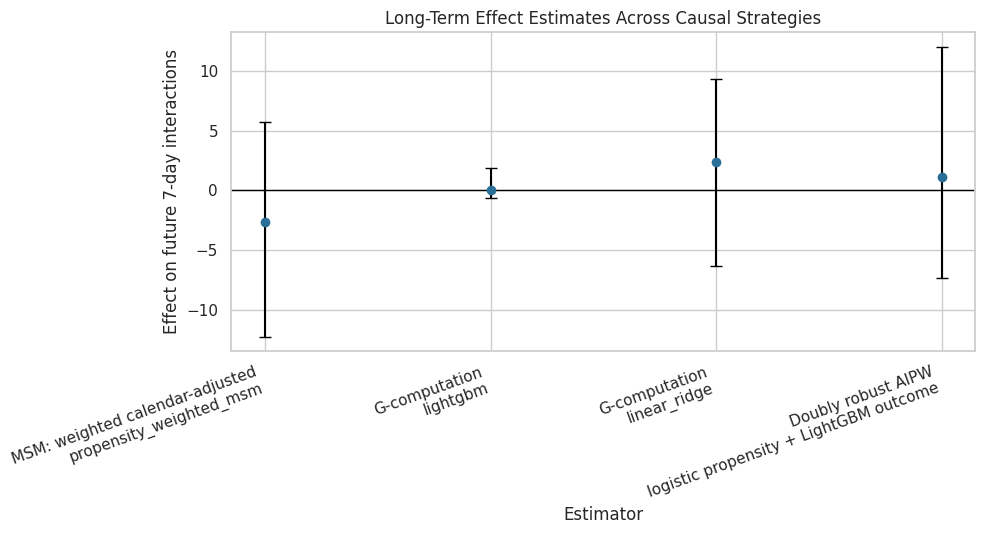

In [11]:
comparison_plot = estimator_comparison_with_aipw.copy()
comparison_plot["label"] = comparison_plot["method"] + "\n" + comparison_plot["model"]
comparison_plot["lower_error"] = comparison_plot["estimate"] - comparison_plot["ci_95_lower"]
comparison_plot["upper_error"] = comparison_plot["ci_95_upper"] - comparison_plot["estimate"]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.errorbar(
    x=np.arange(len(comparison_plot)),
    y=comparison_plot["estimate"],
    yerr=[comparison_plot["lower_error"], comparison_plot["upper_error"]],
    fmt="o",
    color="#2A6F97",
    ecolor="black",
    capsize=4,
)
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(np.arange(len(comparison_plot)))
ax.set_xticklabels(comparison_plot["label"], rotation=20, ha="right")
ax.set_title("Long-Term Effect Estimates Across Causal Strategies")
ax.set_ylabel("Effect on future 7-day interactions")
ax.set_xlabel("Estimator")
plt.tight_layout()
plt.show()


The cross-estimator plot is a clean final-modeling diagnostic. Agreement near zero is not a failed project; it is evidence that the data does not support a clear average long-term lift from this treatment definition.


## Create User-History Segments for Heterogeneity

The average effect may hide differences across user states. This cell creates readable segments based on recent interaction volume, recent high-watch share, recent watch ratio, and day of week.


In [12]:
segment_data = panel[
    [
        "user_id",
        "event_date",
        "day_of_week",
        "prior_3day_interactions",
        "prior_3day_high_watch_share",
        "prior_3day_avg_watch_ratio",
        "lag_1_interactions",
    ]
].copy()

segment_data["prior_interactions_bucket"] = pd.qcut(
    segment_data["prior_3day_interactions"],
    q=4,
    duplicates="drop",
).astype(str)
segment_data["prior_high_watch_bucket"] = pd.qcut(
    segment_data["prior_3day_high_watch_share"],
    q=4,
    duplicates="drop",
).astype(str)
segment_data["prior_watch_ratio_bucket"] = pd.qcut(
    segment_data["prior_3day_avg_watch_ratio"],
    q=4,
    duplicates="drop",
).astype(str)
segment_data["lag_interactions_bucket"] = pd.qcut(
    segment_data["lag_1_interactions"],
    q=4,
    duplicates="drop",
).astype(str)

segment_columns = [
    "prior_interactions_bucket",
    "prior_high_watch_bucket",
    "prior_watch_ratio_bucket",
    "lag_interactions_bucket",
    "day_of_week",
]

primary_scores = aipw_scores.query("aipw_score_name == @PRIMARY_AIPW_SCORE_NAME").copy()
primary_scores = primary_scores.merge(
    segment_data[["user_id", "event_date", *[col for col in segment_columns if col != "day_of_week"]]],
    on=["user_id", "event_date"],
    how="left",
    validate="one_to_one",
)

print("Created segment columns:")
for segment_col in segment_columns:
    print(f"- {segment_col}: {primary_scores[segment_col].nunique()} levels")


Created segment columns:
- prior_interactions_bucket: 4 levels
- prior_high_watch_bucket: 4 levels
- prior_watch_ratio_bucket: 4 levels
- lag_interactions_bucket: 4 levels
- day_of_week: 7 levels


The segment columns translate continuous user histories into product-readable groups. This lets us ask whether the doubly robust score is systematically higher or lower for different recent engagement states.


## Estimate Segment-Level Doubly Robust Effects

Segment-level effects are computed by averaging the primary AIPW score within each segment. This is a descriptive heterogeneity view, not a new randomized experiment. Minimum row and user counts are included so tiny segments do not receive too much attention.


In [13]:
def summarize_segment_effects(data, segment_col, score_col="aipw_score", min_rows=100, min_users=10):
    summary = (
        data.groupby(segment_col, observed=True)
        .agg(
            rows=(score_col, "size"),
            users=("user_id", "nunique"),
            treatment_rate=(PRIMARY_TREATMENT, "mean"),
            observed_outcome_mean=(PRIMARY_OUTCOME, "mean"),
            aipw_ate=(score_col, "mean"),
            aipw_score_std=(score_col, "std"),
            gcomp_component=("cate_hat", "mean"),
            mean_propensity=("propensity_logistic", "mean"),
        )
        .reset_index()
        .rename(columns={segment_col: "segment"})
    )
    summary.insert(0, "segment_type", segment_col)
    summary["passes_size_filter"] = (summary["rows"] >= min_rows) & (summary["users"] >= min_users)
    return summary

segment_effect_tables = [summarize_segment_effects(primary_scores, segment_col) for segment_col in segment_columns]
segment_effects = pd.concat(segment_effect_tables, ignore_index=True)
segment_effects = segment_effects.sort_values(["segment_type", "aipw_ate"], ascending=[True, False])

display(segment_effects)


,segment_type,segment,rows,users,treatment_rate,observed_outcome_mean,aipw_ate,aipw_score_std,gcomp_component,mean_propensity,passes_size_filter
21,day_of_week,Tuesday,623,91,0.4912,390.4575,20.0321,750.2361,0.0096,0.4917,True
22,day_of_week,Wednesday,711,91,0.4684,383.1899,1.8366,168.8665,0.0151,0.4673,True
16,day_of_week,Friday,702,91,0.5199,370.7877,0.6318,205.5002,0.0605,0.5201,True
20,day_of_week,Thursday,706,91,0.5057,375.7663,-0.8262,221.5878,0.0502,0.5056,True
18,day_of_week,Saturday,710,91,0.4831,364.3127,-3.2785,165.9187,0.0524,0.4826,True
19,day_of_week,Sunday,621,91,0.5523,400.9678,-3.4574,201.6585,0.0243,0.5517,True
17,day_of_week,Monday,625,91,0.4800,393.7184,-6.4503,170.7878,0.0344,0.4809,True
15,lag_interactions_bucket,"(75.0, 375.0]",1146,91,0.4852,448.0070,16.2174,575.5850,0.0829,0.4860,True
13,lag_interactions_bucket,"(36.0, 53.0]",1158,91,0.5052,384.2660,-1.3738,193.1010,-0.0205,0.4985,True
12,lag_interactions_bucket,"(-0.001, 36.0]",1202,91,0.4917,290.3095,-4.3047,166.3770,-0.0194,0.5013,True


The segment table shows where the AIPW score is more positive or more negative. These patterns are useful for hypothesis generation, but they should be interpreted with uncertainty and support diagnostics.


## Bootstrap Segment-Level Effects

This bootstrap resamples users and recomputes segment-level AIPW means. It gives uncertainty intervals for segment effects while respecting repeated user-days.


In [14]:
def bootstrap_segment_effects(data, segment_col, score_col="aipw_score", n_bootstrap=250, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    user_ids = data["user_id"].unique()
    user_groups = {user_id: group for user_id, group in data.groupby("user_id", sort=False)}
    rows = []
    for bootstrap_id in range(n_bootstrap):
        sampled_users = rng.choice(user_ids, size=len(user_ids), replace=True)
        sample = pd.concat([user_groups[user_id] for user_id in sampled_users], ignore_index=True)
        boot_summary = sample.groupby(segment_col, observed=True)[score_col].mean().reset_index()
        boot_summary["bootstrap_id"] = bootstrap_id
        rows.append(boot_summary.rename(columns={segment_col: "segment", score_col: "aipw_ate"}))
    result = pd.concat(rows, ignore_index=True)
    result.insert(0, "segment_type", segment_col)
    return result

segment_bootstrap_frames = []
for segment_col in segment_columns:
    segment_bootstrap_frames.append(bootstrap_segment_effects(primary_scores, segment_col))

segment_bootstrap = pd.concat(segment_bootstrap_frames, ignore_index=True)
segment_bootstrap_summary = (
    segment_bootstrap.groupby(["segment_type", "segment"])
    .agg(
        bootstrap_reps=("aipw_ate", "size"),
        bootstrap_mean=("aipw_ate", "mean"),
        bootstrap_std=("aipw_ate", "std"),
        ci_95_lower=("aipw_ate", lambda values: values.quantile(0.025)),
        ci_95_upper=("aipw_ate", lambda values: values.quantile(0.975)),
    )
    .reset_index()
)

segment_effects_with_ci = segment_effects.merge(
    segment_bootstrap_summary,
    on=["segment_type", "segment"],
    how="left",
)

display(segment_effects_with_ci)


,segment_type,segment,rows,users,treatment_rate,observed_outcome_mean,aipw_ate,aipw_score_std,gcomp_component,mean_propensity,passes_size_filter,bootstrap_reps,bootstrap_mean,bootstrap_std,ci_95_lower,ci_95_upper
0,day_of_week,Tuesday,623,91,0.4912,390.4575,20.0321,750.2361,0.0096,0.4917,True,250,20.4314,32.7418,-24.3380,90.8593
1,day_of_week,Wednesday,711,91,0.4684,383.1899,1.8366,168.8665,0.0151,0.4673,True,250,2.1471,7.8816,-12.4635,18.6481
2,day_of_week,Friday,702,91,0.5199,370.7877,0.6318,205.5002,0.0605,0.5201,True,250,0.1500,7.1439,-13.5674,13.8208
3,day_of_week,Thursday,706,91,0.5057,375.7663,-0.8262,221.5878,0.0502,0.5056,True,250,-1.4476,8.9724,-19.8088,15.7126
4,day_of_week,Saturday,710,91,0.4831,364.3127,-3.2785,165.9187,0.0524,0.4826,True,250,-3.6206,5.5464,-13.7823,7.3680
5,day_of_week,Sunday,621,91,0.5523,400.9678,-3.4574,201.6585,0.0243,0.5517,True,250,-4.0013,7.8748,-20.5009,9.5415
6,day_of_week,Monday,625,91,0.4800,393.7184,-6.4503,170.7878,0.0344,0.4809,True,250,-6.1623,5.8209,-18.4649,4.0985
7,lag_interactions_bucket,"(75.0, 375.0]",1146,91,0.4852,448.0070,16.2174,575.5850,0.0829,0.4860,True,250,16.0696,18.4124,-9.9926,57.4826
8,lag_interactions_bucket,"(36.0, 53.0]",1158,91,0.5052,384.2660,-1.3738,193.1010,-0.0205,0.4985,True,250,-1.6926,5.6757,-12.9051,9.4193
9,lag_interactions_bucket,"(-0.001, 36.0]",1202,91,0.4917,290.3095,-4.3047,166.3770,-0.0194,0.5013,True,250,-4.3555,3.9523,-11.8921,3.5914


The segment bootstrap intervals show how noisy the heterogeneous effect patterns are. A segment with a large point estimate but a wide interval should be treated as a hypothesis, not an action rule.


## Plot Segment Effects by Recent Interaction Volume

Recent interaction volume is a natural recommender-system state variable. This plot shows whether users with lower or higher recent activity appear to have different doubly robust effects.


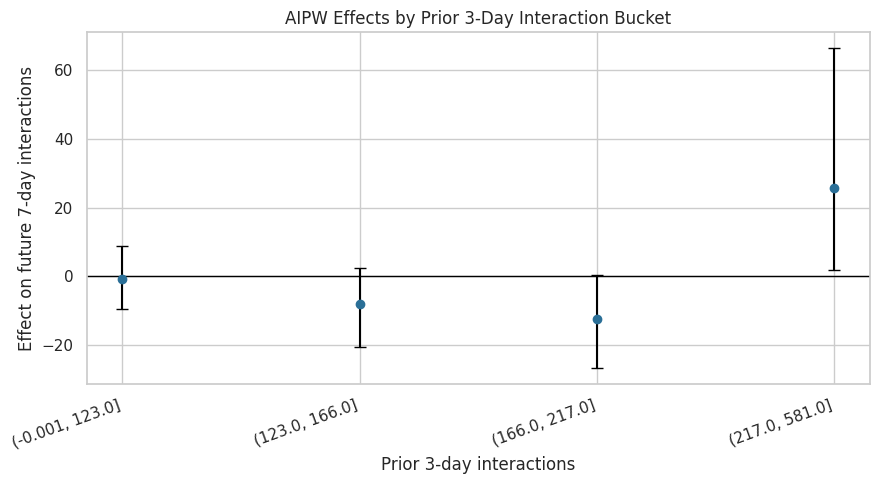

In [15]:
interaction_segment_plot = segment_effects_with_ci.query("segment_type == 'prior_interactions_bucket'").copy()
interaction_segment_plot = interaction_segment_plot.sort_values("segment")
interaction_segment_plot["lower_error"] = interaction_segment_plot["aipw_ate"] - interaction_segment_plot["ci_95_lower"]
interaction_segment_plot["upper_error"] = interaction_segment_plot["ci_95_upper"] - interaction_segment_plot["aipw_ate"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(
    x=np.arange(len(interaction_segment_plot)),
    y=interaction_segment_plot["aipw_ate"],
    yerr=[interaction_segment_plot["lower_error"], interaction_segment_plot["upper_error"]],
    fmt="o",
    color="#2A6F97",
    ecolor="black",
    capsize=4,
)
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(np.arange(len(interaction_segment_plot)))
ax.set_xticklabels(interaction_segment_plot["segment"], rotation=20, ha="right")
ax.set_title("AIPW Effects by Prior 3-Day Interaction Bucket")
ax.set_xlabel("Prior 3-day interactions")
ax.set_ylabel("Effect on future 7-day interactions")
plt.tight_layout()
plt.show()


This plot checks whether the average near-zero effect is hiding differences by recent activity level. If intervals remain wide or cross zero across buckets, the heterogeneity story should stay cautious.


## Plot Segment Effects by Recent Watch Quality

This plot repeats the segment view for recent high-watch share. It asks whether users with recently satisfying watch behavior respond differently to another high-watch-exposure day.


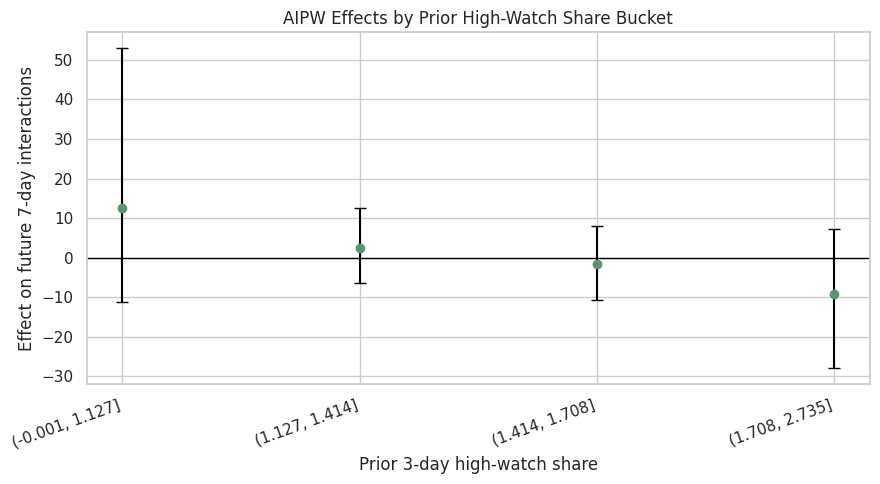

In [16]:
watch_segment_plot = segment_effects_with_ci.query("segment_type == 'prior_high_watch_bucket'").copy()
watch_segment_plot = watch_segment_plot.sort_values("segment")
watch_segment_plot["lower_error"] = watch_segment_plot["aipw_ate"] - watch_segment_plot["ci_95_lower"]
watch_segment_plot["upper_error"] = watch_segment_plot["ci_95_upper"] - watch_segment_plot["aipw_ate"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(
    x=np.arange(len(watch_segment_plot)),
    y=watch_segment_plot["aipw_ate"],
    yerr=[watch_segment_plot["lower_error"], watch_segment_plot["upper_error"]],
    fmt="o",
    color="#5C946E",
    ecolor="black",
    capsize=4,
)
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(np.arange(len(watch_segment_plot)))
ax.set_xticklabels(watch_segment_plot["segment"], rotation=20, ha="right")
ax.set_title("AIPW Effects by Prior High-Watch Share Bucket")
ax.set_xlabel("Prior 3-day high-watch share")
ax.set_ylabel("Effect on future 7-day interactions")
plt.tight_layout()
plt.show()


The watch-quality segment plot connects directly to the treatment definition. It helps answer whether high-watch exposure is more promising for users who were already having high-watch experiences recently.


## Smooth Noisy AIPW Scores with a LightGBM Effect Model

AIPW scores are noisy row-level pseudo-outcomes. To summarize heterogeneity more smoothly, this cell fits a LightGBM regressor that predicts the primary AIPW score from pre-treatment covariates only.

This is not a definitive individual treatment effect model. It is a diagnostic tool for identifying which histories appear to moderate the doubly robust score.


In [17]:
effect_numeric_features = [
    "lag_1_active_day",
    "lag_1_interactions",
    "lag_1_total_play_duration_sec",
    "lag_1_avg_watch_ratio",
    "lag_1_high_watch_share",
    "prior_3day_active_day",
    "prior_3day_interactions",
    "prior_3day_total_play_duration_sec",
    "prior_3day_avg_watch_ratio",
    "prior_3day_high_watch_share",
    "calendar_day_index",
    "panel_day_index",
]
effect_categorical_features = ["day_of_week"]
effect_features = effect_numeric_features + effect_categorical_features

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", effect_numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), effect_categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

effect_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LGBMRegressor(
                n_estimators=120,
                learning_rate=0.04,
                num_leaves=10,
                min_child_samples=60,
                subsample=0.9,
                colsample_bytree=0.9,
                random_state=RANDOM_STATE,
                n_jobs=1,
                verbose=-1,
            ),
        ),
    ]
)

X_effect = primary_scores[effect_features].copy()
y_effect = primary_scores["aipw_score"].astype(float)
groups = primary_scores["user_id"]

group_kfold = GroupKFold(n_splits=5)
effect_pred = np.zeros(len(primary_scores), dtype=float)
effect_metric_rows = []

for fold, (train_idx, test_idx) in enumerate(group_kfold.split(X_effect, y_effect, groups=groups), start=1):
    fold_model = clone(effect_model)
    fold_model.fit(X_effect.iloc[train_idx], y_effect.iloc[train_idx])
    pred = fold_model.predict(X_effect.iloc[test_idx])
    effect_pred[test_idx] = pred
    effect_metric_rows.append(
        {
            "fold": fold,
            "rows": len(test_idx),
            "users": primary_scores.iloc[test_idx]["user_id"].nunique(),
            "rmse": np.sqrt(mean_squared_error(y_effect.iloc[test_idx], pred)),
            "mae": mean_absolute_error(y_effect.iloc[test_idx], pred),
            "r2": r2_score(y_effect.iloc[test_idx], pred),
        }
    )

primary_scores["smoothed_aipw_effect"] = effect_pred
effect_model_metrics = pd.DataFrame(effect_metric_rows)

display(effect_model_metrics)


,fold,rows,users,rmse,mae,r2
0,1,962,19,186.9065,106.7323,-0.0361
1,2,934,18,236.1637,112.2666,0.0117
2,3,934,18,610.4023,132.5208,-0.0014
3,4,934,18,173.2584,108.6869,-0.1550
4,5,934,18,208.2852,99.8468,-0.0115


The effect-smoothing metrics show how predictable the noisy AIPW scores are from pre-treatment history. Modest predictive performance is normal here because AIPW scores include residual noise, but the model can still reveal useful moderator patterns.


## Inspect the Distribution of Smoothed Effects

The smoothed effect distribution is easier to interpret than the raw AIPW score distribution. It shows where the effect model expects more positive or negative long-term impacts based on pre-treatment history.


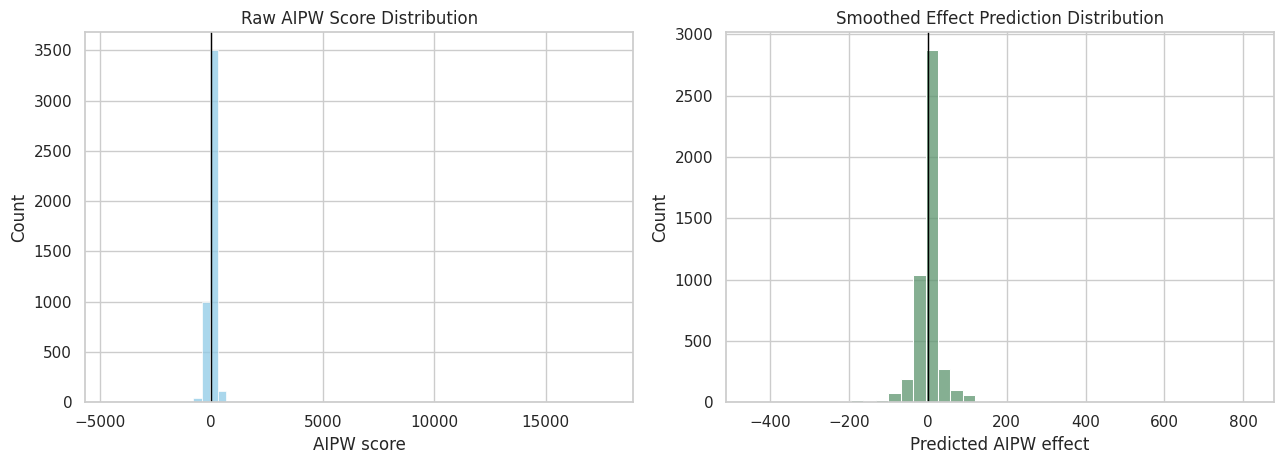

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.histplot(primary_scores["aipw_score"], bins=60, color="#8ECAE6", ax=axes[0])
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Raw AIPW Score Distribution")
axes[0].set_xlabel("AIPW score")

sns.histplot(primary_scores["smoothed_aipw_effect"], bins=40, color="#5C946E", ax=axes[1])
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Smoothed Effect Prediction Distribution")
axes[1].set_xlabel("Predicted AIPW effect")

plt.tight_layout()
plt.show()


The raw AIPW scores are much noisier than the smoothed effect predictions. The smoothed distribution is better for describing heterogeneity, while the average AIPW score remains the main doubly robust estimate.


## Feature Importance for Effect Moderation

The full effect model is fit on all rows so we can inspect feature importances. These importances describe which pre-treatment variables help predict variation in the AIPW pseudo-effect. They should not be read as causal effects of the covariates themselves.


,feature,importance
0,prior_3day_high_watch_share,189
1,lag_1_total_play_duration_sec,150
2,prior_3day_interactions,141
3,lag_1_interactions,132
4,lag_1_avg_watch_ratio,130
5,lag_1_high_watch_share,103
6,prior_3day_total_play_duration_sec,96
7,prior_3day_avg_watch_ratio,78
8,calendar_day_index,43
9,day_of_week_Friday,6


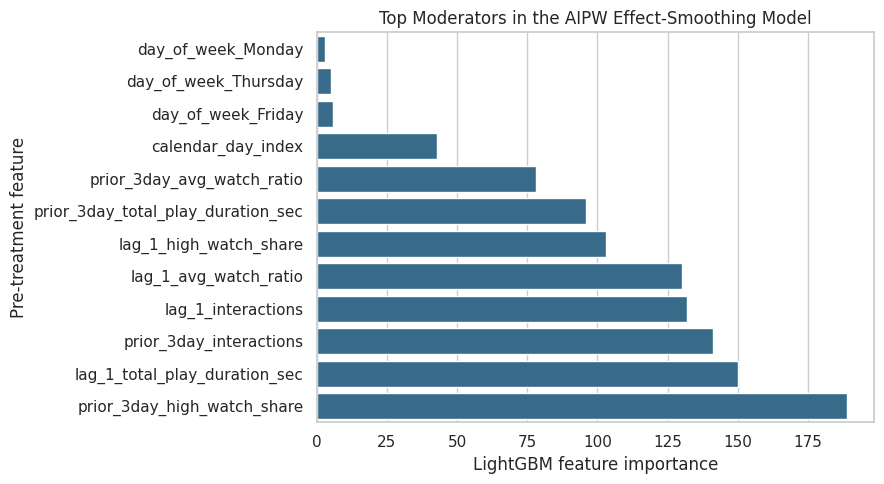

In [19]:
full_effect_model = clone(effect_model).fit(X_effect, y_effect)
feature_names = full_effect_model.named_steps["preprocessor"].get_feature_names_out()
importances = full_effect_model.named_steps["model"].feature_importances_

effect_importance = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(effect_importance.head(15))

fig, ax = plt.subplots(figsize=(9, 5))
plot_importance = effect_importance.head(12).sort_values("importance")
sns.barplot(data=plot_importance, x="importance", y="feature", ax=ax, color="#2A6F97")
ax.set_title("Top Moderators in the AIPW Effect-Smoothing Model")
ax.set_xlabel("LightGBM feature importance")
ax.set_ylabel("Pre-treatment feature")
plt.tight_layout()
plt.show()


The importance table and plot identify which histories are most useful for predicting heterogeneous doubly robust scores. These variables are natural candidates for final-report discussion and future online experiment stratification.


## Smoothed Effects by Predicted Effect Bucket

This cell groups rows by the smoothed effect prediction. It compares predicted effect buckets with observed AIPW scores and treatment rates. This checks whether the effect smoother is separating rows into meaningfully different pseudo-effect groups.


In [20]:
primary_scores["smoothed_effect_bucket"] = pd.qcut(
    primary_scores["smoothed_aipw_effect"],
    q=5,
    duplicates="drop",
).astype(str)

smoothed_bucket_summary = (
    primary_scores.groupby("smoothed_effect_bucket", observed=True)
    .agg(
        rows=("aipw_score", "size"),
        users=("user_id", "nunique"),
        treatment_rate=(PRIMARY_TREATMENT, "mean"),
        observed_outcome_mean=(PRIMARY_OUTCOME, "mean"),
        mean_raw_aipw_score=("aipw_score", "mean"),
        mean_smoothed_effect=("smoothed_aipw_effect", "mean"),
        mean_prior_interactions=("prior_3day_interactions", "mean"),
        mean_prior_high_watch_share=("prior_3day_high_watch_share", "mean"),
    )
    .reset_index()
)

display(smoothed_bucket_summary)


,smoothed_effect_bucket,rows,users,treatment_rate,observed_outcome_mean,mean_raw_aipw_score,mean_smoothed_effect,mean_prior_interactions,mean_prior_high_watch_share
0,"(-11.184, -2.468]",939,91,0.4696,374.1214,6.9171,-5.7183,161.5474,1.3829
1,"(-2.468, 2.224]",953,91,0.4711,352.1794,-7.3628,-0.1343,151.4974,1.3917
2,"(-447.053, -11.184]",940,91,0.5681,393.0787,0.0059,-45.8042,170.6777,1.5720
3,"(11.278, 814.396]",940,91,0.4926,394.0340,9.0918,41.2670,201.3787,1.3727
4,"(2.224, 11.278]",926,90,0.4968,397.6361,-3.1214,5.9372,180.8920,1.4077


The bucket summary turns the effect model into a readable heterogeneity diagnostic. If higher predicted-effect buckets also have higher raw AIPW scores, the smoother is capturing a real pattern rather than arbitrary noise.


## Save Doubly Robust and Heterogeneity Artifacts

This cell saves the AIPW estimates, bootstrap intervals, row-level scores, segment effects, smoothed effect predictions, and updated cross-estimator comparison table.


In [21]:
aipw_results_path = PROCESSED_DIR / "kuairec_long_term_aipw_results.csv"
aipw_scores_path = PROCESSED_DIR / "kuairec_long_term_aipw_scores.parquet"
aipw_bootstrap_path = PROCESSED_DIR / "kuairec_long_term_aipw_bootstrap.csv"
comparison_with_aipw_path = PROCESSED_DIR / "kuairec_long_term_estimator_comparison_with_aipw.csv"
segment_effects_path = PROCESSED_DIR / "kuairec_long_term_aipw_segment_effects.csv"
segment_bootstrap_path = PROCESSED_DIR / "kuairec_long_term_aipw_segment_bootstrap.csv"
effect_predictions_path = PROCESSED_DIR / "kuairec_long_term_effect_model_predictions.parquet"
effect_importance_path = PROCESSED_DIR / "kuairec_long_term_effect_moderator_importance.csv"
effect_metrics_path = PROCESSED_DIR / "kuairec_long_term_effect_model_metrics.csv"
smoothed_bucket_path = PROCESSED_DIR / "kuairec_long_term_smoothed_effect_buckets.csv"

save_score_cols = [
    "user_id",
    "event_date",
    PRIMARY_TREATMENT,
    PRIMARY_OUTCOME,
    "propensity_model",
    "outcome_model",
    "aipw_score_name",
    "aipw_score",
    "pred_y1",
    "pred_y0",
    "cate_hat",
    "propensity_logistic",
    "propensity_lightgbm",
]

aipw_results.to_csv(aipw_results_path, index=False)
aipw_scores[save_score_cols].to_parquet(aipw_scores_path, index=False)
aipw_bootstrap.to_csv(aipw_bootstrap_path, index=False)
estimator_comparison_with_aipw.to_csv(comparison_with_aipw_path, index=False)
segment_effects_with_ci.to_csv(segment_effects_path, index=False)
segment_bootstrap.to_csv(segment_bootstrap_path, index=False)
primary_scores[[
    "user_id",
    "event_date",
    PRIMARY_TREATMENT,
    PRIMARY_OUTCOME,
    "aipw_score",
    "smoothed_aipw_effect",
    *segment_columns,
]].to_parquet(effect_predictions_path, index=False)
effect_importance.to_csv(effect_importance_path, index=False)
effect_model_metrics.to_csv(effect_metrics_path, index=False)
smoothed_bucket_summary.to_csv(smoothed_bucket_path, index=False)

print("Saved Notebook 06 artifacts:")
print(f"- {aipw_results_path}")
print(f"- {aipw_scores_path}")
print(f"- {aipw_bootstrap_path}")
print(f"- {comparison_with_aipw_path}")
print(f"- {segment_effects_path}")
print(f"- {segment_bootstrap_path}")
print(f"- {effect_predictions_path}")
print(f"- {effect_importance_path}")
print(f"- {effect_metrics_path}")
print(f"- {smoothed_bucket_path}")


Saved Notebook 06 artifacts:
- /home/apex/Documents/ranking_sys/data/processed/kuairec_long_term_aipw_results.csv
- /home/apex/Documents/ranking_sys/data/processed/kuairec_long_term_aipw_scores.parquet
- /home/apex/Documents/ranking_sys/data/processed/kuairec_long_term_aipw_bootstrap.csv
- /home/apex/Documents/ranking_sys/data/processed/kuairec_long_term_estimator_comparison_with_aipw.csv
- /home/apex/Documents/ranking_sys/data/processed/kuairec_long_term_aipw_segment_effects.csv
- /home/apex/Documents/ranking_sys/data/processed/kuairec_long_term_aipw_segment_bootstrap.csv
- /home/apex/Documents/ranking_sys/data/processed/kuairec_long_term_effect_model_predictions.parquet
- /home/apex/Documents/ranking_sys/data/processed/kuairec_long_term_effect_moderator_importance.csv
- /home/apex/Documents/ranking_sys/data/processed/kuairec_long_term_effect_model_metrics.csv
- /home/apex/Documents/ranking_sys/data/processed/kuairec_long_term_smoothed_effect_buckets.csv


The doubly robust artifacts are saved for the final report notebook. The most important file is the updated estimator comparison table, because it now contains MSM, g-computation, and AIPW estimates side by side.


## Takeaways and Next Step

This notebook added a doubly robust estimator and a heterogeneity layer to the long-term causal effects project.

The AIPW estimates should be interpreted alongside the MSM and g-computation estimates. If all three strategies remain small and uncertain, the final project conclusion should be honest: the current KuaiRec analysis does not show a clear average long-term interaction-volume gain from high-watch-exposure days.

The heterogeneity results are still useful. They show how the effect may vary by recent engagement state, and they provide product hypotheses for future online testing. The final notebook should now combine the estimator comparison, sensitivity checks, segment findings, limitations, and resume-ready summary into a polished report.
